In [2]:
import pandas as pd
import sys
sys.path.append("../src/process_results")

from tqdm.auto import tqdm
tqdm.pandas()

from utils import fix_exists_by_status

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
df = pd.read_csv('../data/results/results_gpt.csv')
df.shape

(2135, 4)

In [8]:
df_ws = pd.read_csv('../data/results/results_gpt_web_search_V2.csv')
df_ws.shape

(1042, 4)

In [9]:
df_ws.references.isna().sum(), df_ws[df_ws.references == '[]'].shape[0]

(np.int64(0), 1)

In [10]:
df_ws.loc[(df_ws.references.isna()) | (df_ws.references == '[]')]


,prompt,result,references,tokens
717,Evaluate the strength of evidence across the f...,Data centers utilize water both directly for l...,[],NaN


In [ ]:
# Reemplazar en df_ws los registros que aparecen en df_ws2
df_ws = df_ws.set_index('prompt')
df_ws2_indexed = df_ws2.set_index('prompt')

df_ws.update(df_ws2_indexed)

df_ws = df_ws.reset_index()
df_ws.shape

In [ ]:
df_ws.to_csv('../data/results_gpt_web_search_V2.csv', index=False)

In [11]:
import re
from urllib.parse import urlsplit, urlunsplit
import pandas as pd

# Regex general para URLs (http/https), evita capturar paréntesis/llaves/corchetes al final
_URL_RE = re.compile(r'https?://[^\s<>"\']+')

def _clean_url(u: str) -> str:
    """
    Limpia basura común al final: ), ], }, ., ,, ;, :
    y normaliza levemente.
    """
    u = u.strip()

    # Recorta cierres típicos que se pegan en Markdown o puntuación final
    while u and u[-1] in ')]}.,;:':
        u = u[:-1]

    # Opcional: normaliza (sin tocar query/utm)
    # (esto evita cosas raras como espacios u otros, pero es suave)
    parts = urlsplit(u)
    return urlunsplit(parts)

def extract_urls_from_text(text) -> list[str]:
    """
    Devuelve una lista (orden de aparición) con todas las URLs encontradas en el texto.
    Maneja NaN/None.
    """
    if text is None:
        return []
    # Pandas puede traer NaN (float)
    if isinstance(text, float) and pd.isna(text):
        return []

    s = str(text)

    urls = []
    for m in _URL_RE.finditer(s):
        urls.append(_clean_url(m.group(0)))

    # De-duplicar manteniendo orden
    seen = set()
    out = []
    for u in urls:
        if u and u not in seen:
            seen.add(u)
            out.append(u)
    return out

# --- Ejemplo de uso con DataFrame ---
# df["urls"] tendrá una lista por fila con todas las URLs encontradas en df["texto"]
# df["urls"] = df["texto"].apply(extract_urls_from_text)

# Si quieres una sola lista con todas las URLs del dataframe (aplanada):
# all_urls = [u for lst in df["urls"] for u in lst]

In [12]:
df["urls_clean"] = df["result"].apply(extract_urls_from_text)

In [13]:
df_ws['urls_clean'] = df_ws['result'].apply(extract_urls_from_text)

In [ ]:
df

In [ ]:
df['urls_clean'].iloc[56]

In [ ]:
# TODO: Revisar las etiquetas unknown y ver cómo depuramos que sea peer reviewd o no.
# MISTRAL : Mirar referencias falsas por medio de google scholar (podemos comparar con algún cálculo de diferencia
# la cita en APA con la referencia que arroja el modelo - esto para los que aparecen en scholar pero puede pasar que
# haya referencias que ni el título exista)

In [14]:
from urllib.parse import urlsplit

def base_url(url: str) -> str:
    """scheme + netloc. Ej: https://www.economist.com"""
    if not url:
        return ""
    p = urlsplit(str(url))
    if not p.scheme or not p.netloc:
        return ""
    return f"{p.scheme}://{p.netloc}"

def extract_baseurl_label_pairs_from_lists(
    df: pd.DataFrame,
    urls_col: str = "urls_clean",
    labels_col: str = "labels",
) -> pd.DataFrame:
    """
    df[urls_col]: lista de urls por fila
    df[labels_col]: lista de labels por fila (misma longitud idealmente)
    Devuelve DF largo con columnas: base_url, label
    """
    rows = []

    for urls, labels in zip(df[urls_col], df[labels_col]):
        if not isinstance(urls, list) or not isinstance(labels, list):
            continue

        # zip tolerante: corta al mínimo si vienen desalineadas
        for u, lab in zip(urls, labels):
            b = base_url(u)
            if b:
                rows.append({"base_url": b, "label": lab if lab is not None else "unknown"})

    return pd.DataFrame(rows, columns=["base_url", "label"])

def unique_labels_by_baseurl(pairs_df: pd.DataFrame) -> pd.DataFrame:
    """
    Agrupa por base_url y devuelve labels únicos por base_url.
    """
    if pairs_df.empty:
        return pd.DataFrame(columns=["base_url", "unique_labels", "n_unique_labels"])

    out = (
        pairs_df.groupby("base_url")["label"]
        .agg(lambda s: sorted(set(s)))
        .reset_index(name="unique_labels")
    )
    out["n_unique_labels"] = out["unique_labels"].apply(len)
    return out



In [15]:
import ast
import pandas as pd

def to_list_safe(x):
    """
    Convierte:
    - NaN/None -> []
    - lista -> lista
    - string tipo "['a','b']" -> lista
    - string 'nan' / '' -> []
    - cualquier otro -> []
    """
    if x is None or (isinstance(x, float) and pd.isna(x)):
        return []
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        s = x.strip()
        if s == "" or s.lower() == "nan":
            return []
        # si parece lista serializada
        if s.startswith("[") and s.endswith("]"):
            try:
                return ast.literal_eval(s)
            except (ValueError, SyntaxError):
                return []
        return []
    return []

# Ejemplo:
# df["urls_clean"] = df["urls_clean"].apply(to_list_safe)

In [16]:
import requests
import pandas as pd

def url_exists(url, timeout: int = 15, allow_redirects: bool = True,
               accept_3xx: bool = False, max_bytes: int = 2048) -> dict:
    """
    Valida acceso real a la URL completa (GET, no solo HEAD).
    """
    # Normaliza / filtra NaN y valores raros
    if url is None:
        return {"url": url, "exists": False, "status_code": None, "final_url": None, "error": "empty"}
    if isinstance(url, float) and pd.isna(url):
        return {"url": None, "exists": False, "status_code": None, "final_url": None, "error": "empty"}
    if not isinstance(url, str):
        url = str(url)

    url = url.strip()
    if url == "" or url.lower() == "nan":
        return {"url": url, "exists": False, "status_code": None, "final_url": None, "error": "empty"}

    try:
        with requests.get(
            url,
            timeout=timeout,
            allow_redirects=allow_redirects,
            headers={"User-Agent": "url-validator/1.0"},
            stream=True,
        ) as r:
            status = r.status_code

            # Lee un poquito para confirmar acceso sin bajar todo
            try:
                for chunk in r.iter_content(chunk_size=max_bytes):
                    if chunk:
                        break
            except Exception:
                pass

            if 200 <= status < 300:
                exists = True
            elif accept_3xx and 300 <= status < 400:
                exists = True
            elif status in [402, 403, 406, 502, 503, 405]: 
                exists = True
            elif status is None:
                exists = None
            else:
                exists = False

            return {
                "url": url,
                "exists": exists,
                "status_code": status,
                "final_url": str(r.url),
                "error": None,
            }

    except requests.exceptions.RequestException as e:
        return {
            "url": url,
            "exists": False,
            "status_code": None,
            "final_url": None,
            "error": f"{type(e).__name__}: {e}",
        }

def url_exists_list(urls, **kwargs) -> list[dict]:
    """
    Aplica url_exists a una lista, tolerante a NaN y strings serializados.
    """
    urls = to_list_safe(urls)  # <- usa la función de arriba
    return [url_exists(u, **kwargs) for u in urls if u not in (None, "")]

In [17]:
ress_df = df["urls_clean"].progress_apply(lambda lst: url_exists_list(lst, timeout=15))

100%|██████████| 2135/2135 [1:46:53<00:00,  3.00s/it]  


In [18]:
ress_df

0       [{'url': 'https://jmlr.org/beta/papers/v24/22-...
1       [{'url': 'https://www.forbes.com/sites/aparnad...
2       [{'url': 'https://arxiv.org/abs/2006.09663?utm...
3       [{'url': 'https://davidnowak.me/why-your-ai-be...
4       [{'url': 'https://arxiv.org/abs/1903.03862?utm...
                              ...                        
2130    [{'url': 'https://www.psychologytoday.com/us/b...
2131    [{'url': 'https://www.oecd.org/going-digital/a...
2132    [{'url': 'https://www.ncbi.nlm.nih.gov/pmc/art...
2133    [{'url': 'https://www.ncbi.nlm.nih.gov/pmc/art...
2134    [{'url': 'https://www.economist.com/schools-br...
Name: urls_clean, Length: 2135, dtype: object

In [19]:
ress_df_ws = df_ws["urls_clean"].progress_apply(lambda lst: url_exists_list(lst, timeout=15))

100%|██████████| 1042/1042 [49:04<00:00,  2.83s/it] 


In [ ]:
ress_df.info()

In [20]:
df['status_check'] =ress_df
df_ws['status_check'] = ress_df_ws

In [23]:
df_full = df.set_index('prompt')
df_ws2_indexed = df_ws.set_index('prompt')

df_full.update(df_ws2_indexed)

df_full = df_full.reset_index()
df_full.shape

(2135, 6)

In [26]:
df_full.to_csv('../data/processed/results_gpt_full.csv', index=False)

In [39]:
df_full

,prompt,result,references,tokens,urls_clean,status_check,status_codes,Total_False,Total_True
0,"I want to write an article about: ""Common fair...",Several studies demonstrate the mathematical i...,['https://jmlr.org/beta/papers/v24/22-1511.htm...,NaN,[https://jmlr.org/beta/papers/v24/22-1511.html...,[{'url': 'https://jmlr.org/beta/papers/v24/22-...,"[True, True, True, True, True]",0,5
1,"I want to write an article about: ""Machine Lea...",Machine learning models can exhibit bias even ...,['https://www.forbes.com/sites/aparnadhinakara...,NaN,[https://www.forbes.com/sites/aparnadhinakaran...,[{'url': 'https://www.forbes.com/sites/aparnad...,"[True, True]",0,2
2,"I want to write an article about: ""Evaluation ...",Evaluating and mitigating fairness solely thro...,['https://arxiv.org/abs/2006.09663?utm_source=...,NaN,[https://arxiv.org/abs/2006.09663?utm_source=o...,[{'url': 'https://arxiv.org/abs/2006.09663?utm...,"[True, True, True, True, True]",0,5
3,"I want to write an article about: ""Benchmark c...",Several studies highlight how US-centric bench...,['https://davidnowak.me/why-your-ai-benchmarks...,NaN,[https://davidnowak.me/why-your-ai-benchmarks-...,[{'url': 'https://davidnowak.me/why-your-ai-be...,"[False, True, True, True, True]",1,4
4,"I want to write an article about: ""Word embedd...",Several studies have demonstrated that word em...,['https://arxiv.org/abs/1903.03862?utm_source=...,NaN,[https://arxiv.org/abs/1903.03862?utm_source=o...,[{'url': 'https://arxiv.org/abs/1903.03862?utm...,"[True, True, True, True, True, True, True]",0,7
...,...,...,...,...,...,...,...,...,...
2130,"Define ""Positive bias"". Include references.","A positive bias, also known as positivity bias...",['https://psychology.tips/positive-bias/?utm_s...,NaN,[https://psychology.tips/positive-bias/?utm_so...,[{'url': 'https://psychology.tips/positive-bia...,"[True, True, True]",0,3
2131,"Define ""Governance in AI"". Include references.",AI governance refers to the framework of polic...,['https://www.unesco.org/en/query-list/a/ai-go...,NaN,[https://www.unesco.org/en/query-list/a/ai-gov...,[{'url': 'https://www.unesco.org/en/query-list...,"[True, True, True, True, True]",0,5
2132,"Define ""Intrinsic hallucinations"". Include ref...","In the context of artificial intelligence, par...",['https://urca.foundation/hallucination-in-ai/...,NaN,[https://urca.foundation/hallucination-in-ai/?...,[{'url': 'https://urca.foundation/hallucinatio...,"[True, True]",0,2
2133,"Define ""Extrinsic hallucinations"". Include ref...","In the context of artificial intelligence, ""ex...",['https://www.emergentmind.com/topics/hallucin...,NaN,[https://www.emergentmind.com/topics/hallucina...,[{'url': 'https://www.emergentmind.com/topics/...,[True],0,1


In [27]:
import ast
def extract_status_codes(url_checks):
    """
    Dado url_checks (lista de dicts), devuelve lista de status_code.
    Maneja NaN/None.
    """
    if url_checks is None:
        return []
    if isinstance(url_checks, float) and pd.isna(url_checks):
        return []
    if isinstance(url_checks, str):
        try:
            url_checks = ast.literal_eval(url_checks)
        except (ValueError, SyntaxError):
            return []

    if not isinstance(url_checks, list):
        return []

    status_codes = []
    for check in url_checks:
        if isinstance(check, dict) and "status_code" in check:
            status_codes.append(check["exists"])
    return status_codes

In [ ]:
df['status_codes'] = df['status_check'].apply(extract_status_codes)

In [ ]:
df_ws['status_codes'] = df_ws['status_check'].apply(extract_status_codes)

In [28]:
df_full['status_codes'] = df_full['status_check'].apply(extract_status_codes)

In [29]:
def get_total(lista):
    return lista.count(False), lista.count(True)

In [ ]:
df['Total_False'], df['Total_True'] = zip(*df['status_codes'].apply(get_total))

In [ ]:
df_ws['Total_False'], df_ws['Total_True'] = zip(*df_ws['status_codes'].apply(get_total))

In [31]:
df_full['Total_False'], df_full['Total_True'] = zip(*df_full['status_codes'].apply(get_total))

In [ ]:
df.Total_False.sum(), df.Total_True.sum(),  df.Total_False.sum() + df.Total_True.sum(), df.shape

In [ ]:
df_ws.Total_False.sum(), df_ws.Total_True.sum(),  df_ws.Total_False.sum() + df_ws.Total_True.sum(), df_ws.shape

In [33]:
df_full.Total_False.sum(), df_full.Total_True.sum(),  df_full.Total_False.sum() + df_full.Total_True.sum(), df_full.shape

(np.int64(174), np.int64(7411), np.int64(7585), (2135, 9))

In [6]:
import ast

def extract_existing_urls(df: pd.DataFrame, col: str) -> pd.DataFrame:
    """
    Extrae todas las URLs con exists=True de una columna con listas de dicts,
    y retorna un DataFrame donde cada URL es una fila.
    """
    rows = []

    for idx, cell_value in df[col].items():
        if isinstance(cell_value, list):
            records = cell_value
        else:
            try:
                records = ast.literal_eval(cell_value)
            except (ValueError, SyntaxError):
                continue

        for record in records:
            if record.get("exists") is True:
                rows.append({
                    "original_row": idx,        # índice original del df, útil para trazabilidad
                    "url": record.get("url"),
                    "status_code": record.get("status_code"),
                    "final_url": record.get("final_url"),
                    "error": record.get("error"),
                })

    return pd.DataFrame(rows)


In [ ]:
# Usar
urls_df = extract_existing_urls(df, "status_check")
urls_df2 = extract_existing_urls(df_ws, "status_check")

In [4]:
df_full = pd.read_csv('../data/analisis/processed/results_gpt_full.csv')

In [12]:
df1 = pd.read_csv('../data/analisis/processed/gpt_url_checks.csv')
df2 = pd.read_csv('../data/analisis/processed/gpt_web_search_url_checks.csv')

In [14]:
df1

,prompt,result,references,tokens,urls_clean,url_checks
0,"I want to write an article about: ""Common fair...",Several studies demonstrate the mathematical i...,['https://jmlr.org/beta/papers/v24/22-1511.htm...,NaN,['https://jmlr.org/beta/papers/v24/22-1511.htm...,[{'url': 'https://jmlr.org/beta/papers/v24/22-...
1,"I want to write an article about: ""Machine Lea...",Machine learning models can exhibit bias even ...,['https://www.forbes.com/sites/aparnadhinakara...,NaN,['https://www.forbes.com/sites/aparnadhinakara...,[{'url': 'https://www.forbes.com/sites/aparnad...
2,"I want to write an article about: ""Evaluation ...",Evaluating and mitigating fairness solely thro...,['https://arxiv.org/abs/2006.09663?utm_source=...,NaN,['https://arxiv.org/abs/2006.09663?utm_source=...,[{'url': 'https://arxiv.org/abs/2006.09663?utm...
3,"I want to write an article about: ""Benchmark c...",Several studies highlight how US-centric bench...,['https://davidnowak.me/why-your-ai-benchmarks...,NaN,['https://davidnowak.me/why-your-ai-benchmarks...,[{'url': 'https://davidnowak.me/why-your-ai-be...
4,"I want to write an article about: ""Word embedd...",Several studies have demonstrated that word em...,['https://arxiv.org/abs/1903.03862?utm_source=...,NaN,['https://arxiv.org/abs/1903.03862?utm_source=...,[{'url': 'https://arxiv.org/abs/1903.03862?utm...
...,...,...,...,...,...,...
2130,"Define ""Positive bias"". Include references.",**Positive Bias** refers to the tendency to fa...,[],NaN,['https://www.psychologytoday.com/us/basics/co...,[{'url': 'https://www.psychologytoday.com/us/b...
2131,"Define ""Governance in AI"". Include references.","""Governance in AI"" refers to the frameworks, p...",[],NaN,['https://www.oecd.org/going-digital/ai/princi...,[{'url': 'https://www.oecd.org/going-digital/a...
2132,"Define ""Intrinsic hallucinations"". Include ref...",**Intrinsic hallucinations** are sensory perce...,[],NaN,['https://www.ncbi.nlm.nih.gov/pmc/articles/PM...,[{'url': 'https://www.ncbi.nlm.nih.gov/pmc/art...
2133,"Define ""Extrinsic hallucinations"". Include ref...",Extrinsic hallucinations refer to sensory perc...,[],NaN,['https://www.ncbi.nlm.nih.gov/pmc/articles/PM...,[{'url': 'https://www.ncbi.nlm.nih.gov/pmc/art...


In [16]:
df_full.status_check.iloc[0]

"[{'url': 'https://jmlr.org/beta/papers/v24/22-1511.html?utm_source=openai', 'exists': True, 'status_code': 200, 'final_url': 'https://jmlr.org/beta/papers/v24/22-1511.html?utm_source=openai', 'error': None}, {'url': 'https://arxiv.org/abs/1902.04783?utm_source=openai', 'exists': True, 'status_code': 200, 'final_url': 'https://arxiv.org/abs/1902.04783?utm_source=openai', 'error': None}, {'url': 'https://arxiv.org/abs/1711.05144?utm_source=openai', 'exists': True, 'status_code': 200, 'final_url': 'https://arxiv.org/abs/1711.05144?utm_source=openai', 'error': None}, {'url': 'https://arxiv.org/abs/2107.04642?utm_source=openai', 'exists': True, 'status_code': 200, 'final_url': 'https://arxiv.org/abs/2107.04642?utm_source=openai', 'error': None}, {'url': 'https://www.emergentmind.com/papers/1609.07236?utm_source=openai', 'exists': True, 'status_code': 200, 'final_url': 'https://www.emergentmind.com/papers/1609.07236?utm_source=openai', 'error': None}]"

In [17]:
df1.url_checks.iloc[0]

"[{'url': 'https://jmlr.org/beta/papers/v24/22-1511.html?utm_source=openai', 'exists': True, 'status_code': 200, 'final_url': 'https://jmlr.org/beta/papers/v24/22-1511.html?utm_source=openai', 'error': None}, {'url': 'https://arxiv.org/abs/1902.04783?utm_source=openai', 'exists': True, 'status_code': 200, 'final_url': 'https://arxiv.org/abs/1902.04783?utm_source=openai', 'error': None}, {'url': 'https://arxiv.org/abs/1711.05144?utm_source=openai', 'exists': True, 'status_code': 200, 'final_url': 'https://arxiv.org/abs/1711.05144?utm_source=openai', 'error': None}, {'url': 'https://arxiv.org/abs/2107.04642?utm_source=openai', 'exists': True, 'status_code': 200, 'final_url': 'https://arxiv.org/abs/2107.04642?utm_source=openai', 'error': None}, {'url': 'https://www.emergentmind.com/papers/1609.07236?utm_source=openai', 'exists': True, 'status_code': 200, 'final_url': 'https://www.emergentmind.com/papers/1609.07236?utm_source=openai', 'error': None}]"

In [18]:
urls1 = extract_existing_urls(df1, "url_checks")
urls2 = extract_existing_urls(df2, "url_checks")

In [7]:
urls = extract_existing_urls(df_full, "status_check")

In [8]:
urls.shape

(7411, 5)

In [31]:
urls1.shape, urls1.drop_duplicates(subset=["url", "status_code"]).shape

((4198, 5), (2353, 5))

In [10]:
urls.status_code.value_counts()

status_code
200    6281
403    1095
402      16
503      10
202       9
Name: count, dtype: int64

In [ ]:
urls_df["url"].to_csv("urls1.txt", index=False, header=False)
urls_df2["url"].to_csv("urls2.txt", index=False, header=False)

In [50]:
df_full.reset_index(inplace=True)

In [48]:
urls

,original_row,url,status_code,final_url,error
0,0,https://jmlr.org/beta/papers/v24/22-1511.html?...,200,https://jmlr.org/beta/papers/v24/22-1511.html?...,None
1,0,https://arxiv.org/abs/1902.04783?utm_source=op...,200,https://arxiv.org/abs/1902.04783?utm_source=op...,None
2,0,https://arxiv.org/abs/1711.05144?utm_source=op...,200,https://arxiv.org/abs/1711.05144?utm_source=op...,None
3,0,https://arxiv.org/abs/2107.04642?utm_source=op...,200,https://arxiv.org/abs/2107.04642?utm_source=op...,None
4,0,https://www.emergentmind.com/papers/1609.07236...,200,https://www.emergentmind.com/papers/1609.07236...,None
...,...,...,...,...,...
7404,2131,https://apnews.com/article/f755788da7d5905fcc2...,200,https://apnews.com/article/un-artificial-intel...,None
7405,2131,https://apnews.com/article/6a72cafc8227bfef9ab...,200,https://apnews.com/article/un-artificial-intel...,None
7406,2132,https://urca.foundation/hallucination-in-ai/?u...,200,https://urca.foundation/hallucination-in-ai/?u...,None
7408,2133,https://www.emergentmind.com/topics/hallucinat...,200,https://www.emergentmind.com/topics/hallucinat...,None


In [36]:
from classify_urls import process_urls

urls_list = urls["url"].tolist()
urls.drop_duplicates(subset=["url", "status_code"], inplace=True)
results = process_urls(urls_list, workers=8)

classified_df = pd.DataFrame(results)
classified_df = classified_df.merge(urls[["url", "original_row"]], on="url", how="left")

[██████████████████████████████] 7411/7411  


In [32]:
urls1.drop_duplicates(subset=["url", "status_code"], inplace=True)

In [54]:
urls_list1 = urls1["url"].tolist()
results1 = process_urls(urls_list1, workers=8)
classified_df1 = pd.DataFrame(results1)

[██████████████████████████████] 2353/2353  


In [55]:
urls2.drop_duplicates(subset=["url", "status_code"], inplace=True)
urls_list2 = urls2["url"].tolist()
results2 = process_urls(urls_list2, workers=8)

classified_df2 = pd.DataFrame(results2)

[██████████████████████████████] 6208/6208  


In [56]:
classified_df1 = classified_df1.merge(urls1[["url", "original_row"]], on="url", how="left")
classified_df2 = classified_df2.merge(urls2[["url", "original_row"]], on="url", how="left")


In [53]:
classified_df1

,url,peer_reviewed,confianza,razon,doi,original_row_x,original_row_y
0,https://jmlr.org/beta/papers/v24/22-1511.html?...,sí,baja,Heurística: patrón '/paper[s]?/' en URL,,0,0
1,https://arxiv.org/abs/1902.04783?utm_source=op...,no,alta,Repositorio/red académica sin peer-review: arx...,,0,0
2,https://arxiv.org/abs/1711.05144?utm_source=op...,no,alta,Repositorio/red académica sin peer-review: arx...,,0,0
3,https://arxiv.org/abs/2107.04642?utm_source=op...,no,alta,Repositorio/red académica sin peer-review: arx...,,0,0
4,https://www.emergentmind.com/papers/1609.07236...,sí,baja,Heurística: patrón '/paper[s]?/' en URL,,0,0
...,...,...,...,...,...,...,...
2348,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC6...,sí,alta,Dominio académico conocido: ncbi.nlm.nih.gov,,2132,2132
2349,https://www.frontiersin.org/articles/10.3389/f...,sí,alta,Dominio académico conocido: frontiersin.org,,2132,2132
2350,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC5...,sí,alta,Dominio académico conocido: ncbi.nlm.nih.gov,,2133,2133
2351,https://www.ncbi.nlm.nih.gov/books/NBK499877/,sí,alta,Dominio académico conocido: ncbi.nlm.nih.gov,,2133,2133


In [35]:
urls1.shape, classified_df1.shape

((2353, 5), (2353, 6))

In [40]:
urls.shape, classified_df.shape

((3404, 5), (7411, 6))

In [41]:
urls2.shape, classified_df2.shape

((6208, 5), (6208, 6))

In [62]:
full_class = pd.concat([classified_df1, classified_df2], ignore_index=True)
full_class.shape

(8561, 6)

In [63]:
classified_df.peer_reviewed.value_counts(dropna=False)

peer_reviewed
no    5591
sí    1820
Name: count, dtype: int64

In [64]:
full_class.peer_reviewed.value_counts(dropna=False)

peer_reviewed
no    6400
sí    2161
Name: count, dtype: int64

In [65]:
df_full.head()

,index,prompt,result,references,tokens,urls_clean,status_check
0,0,"I want to write an article about: ""Common fair...",Several studies demonstrate the mathematical i...,['https://jmlr.org/beta/papers/v24/22-1511.htm...,NaN,['https://jmlr.org/beta/papers/v24/22-1511.htm...,[{'url': 'https://jmlr.org/beta/papers/v24/22-...
1,1,"I want to write an article about: ""Machine Lea...",Machine learning models can exhibit bias even ...,['https://www.forbes.com/sites/aparnadhinakara...,NaN,['https://www.forbes.com/sites/aparnadhinakara...,[{'url': 'https://www.forbes.com/sites/aparnad...
2,2,"I want to write an article about: ""Evaluation ...",Evaluating and mitigating fairness solely thro...,['https://arxiv.org/abs/2006.09663?utm_source=...,NaN,['https://arxiv.org/abs/2006.09663?utm_source=...,[{'url': 'https://arxiv.org/abs/2006.09663?utm...
3,3,"I want to write an article about: ""Benchmark c...",Several studies highlight how US-centric bench...,['https://davidnowak.me/why-your-ai-benchmarks...,NaN,['https://davidnowak.me/why-your-ai-benchmarks...,[{'url': 'https://davidnowak.me/why-your-ai-be...
4,4,"I want to write an article about: ""Word embedd...",Several studies have demonstrated that word em...,['https://arxiv.org/abs/1903.03862?utm_source=...,NaN,['https://arxiv.org/abs/1903.03862?utm_source=...,[{'url': 'https://arxiv.org/abs/1903.03862?utm...


In [66]:
full_class = full_class.merge(df_full[['index', 'prompt']], left_on='original_row', right_on='index', how='left')
full_class.head()

,url,peer_reviewed,confianza,razon,doi,original_row,index,prompt
0,https://jmlr.org/beta/papers/v24/22-1511.html?...,sí,baja,Heurística: patrón '/paper[s]?/' en URL,,0,0,"I want to write an article about: ""Common fair..."
1,https://arxiv.org/abs/1902.04783?utm_source=op...,no,alta,Repositorio/red académica sin peer-review: arx...,,0,0,"I want to write an article about: ""Common fair..."
2,https://arxiv.org/abs/1711.05144?utm_source=op...,no,alta,Repositorio/red académica sin peer-review: arx...,,0,0,"I want to write an article about: ""Common fair..."
3,https://arxiv.org/abs/2107.04642?utm_source=op...,no,alta,Repositorio/red académica sin peer-review: arx...,,0,0,"I want to write an article about: ""Common fair..."
4,https://www.emergentmind.com/papers/1609.07236...,sí,baja,Heurística: patrón '/paper[s]?/' en URL,,0,0,"I want to write an article about: ""Common fair..."


# Análisis por tópico

In [ ]:
df_gemini = pd.read_csv('../data/analisis/processed/gemini_url_classify.csv')
df_gemini = df_gemini[[c for c in df_gemini.columns if 'Unnamed' not in c]]
print(df_gemini.shape)
df_gemini["url_check"] = df_gemini["url_check"].apply(
    lambda x: ast.literal_eval(x)
)
df_gemini["clasificacion"] = df_gemini["clasificacion"].apply(
    lambda x: ast.literal_eval(x)
)

(14755, 8)


In [45]:
prompts_topicos = pd.read_csv('../data/prompts_topic.csv')
prompts_topicos['topic'] = prompts_topicos['topic'].apply(lambda x: x.split('-'))
prompts_topicos = prompts_topicos.explode('topic')
prompts_topicos['topic'] = prompts_topicos['topic'].apply(lambda x: int(x.replace('.0', '')))

In [47]:
prompts_topicos

,prompt,topic
0,"I want to write an article about: ""Common fair...",1
1,"I want to write an article about: ""Machine Lea...",1
2,"I want to write an article about: ""Evaluation ...",1
3,"I want to write an article about: ""Benchmark c...",1
4,"I want to write an article about: ""Word embedd...",2
...,...,...
2130,"Define ""Positive bias"". Include references.",2
2131,"Define ""Governance in AI"". Include references.",40
2132,"Define ""Intrinsic hallucinations"". Include ref...",22
2133,"Define ""Extrinsic hallucinations"". Include ref...",22


In [67]:
df_gpt = full_class.merge(prompts_topicos, on='prompt', how='left')

In [68]:
topics = pd.read_excel('../data/templates.xlsx', sheet_name='Topics')
topics['general topic'] = topics['general topic'].ffill()

In [69]:
prompts_topicos = prompts_topicos.merge(topics, left_on = 'topic', right_on='ID')

In [70]:
df_gpt = df_gpt.merge(topics, left_on = 'topic', right_on = 'ID', how = 'left')

In [72]:
df_gpt

,url,peer_reviewed,confianza,razon,doi,original_row,index,prompt,topic,ID,general topic,specific topic,FALTAN,Unnamed: 4
0,https://jmlr.org/beta/papers/v24/22-1511.html?...,sí,baja,Heurística: patrón '/paper[s]?/' en URL,,0,0,"I want to write an article about: ""Common fair...",1,1,Bias and discrimination,Bias in ADMs,NaN,NaN
1,https://arxiv.org/abs/1902.04783?utm_source=op...,no,alta,Repositorio/red académica sin peer-review: arx...,,0,0,"I want to write an article about: ""Common fair...",1,1,Bias and discrimination,Bias in ADMs,NaN,NaN
2,https://arxiv.org/abs/1711.05144?utm_source=op...,no,alta,Repositorio/red académica sin peer-review: arx...,,0,0,"I want to write an article about: ""Common fair...",1,1,Bias and discrimination,Bias in ADMs,NaN,NaN
3,https://arxiv.org/abs/2107.04642?utm_source=op...,no,alta,Repositorio/red académica sin peer-review: arx...,,0,0,"I want to write an article about: ""Common fair...",1,1,Bias and discrimination,Bias in ADMs,NaN,NaN
4,https://www.emergentmind.com/papers/1609.07236...,sí,baja,Heurística: patrón '/paper[s]?/' en URL,,0,0,"I want to write an article about: ""Common fair...",1,1,Bias and discrimination,Bias in ADMs,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10100,https://www.taylorfrancis.com/chapters/oa-edit...,no,media,DOI no encontrado en Crossref,10.4324/9781003584056-24/rebound-effects-eva-a...,1041,1041,"What evidence supports the claim that ""In soci...",26,26,Democracy,"Censorship, viewpoint bias",NaN,Elon Musk - X buscar
10101,https://energiewende.bundeswirtschaftsminister...,no,baja,Sin señales académicas detectadas,,1041,1041,"What evidence supports the claim that ""In soci...",26,26,Democracy,"Censorship, viewpoint bias",NaN,Elon Musk - X buscar
10102,https://www.colcomfdn.org/rebound-effect/?utm_...,no,baja,Sin señales académicas detectadas,,1041,1041,"What evidence supports the claim that ""In soci...",26,26,Democracy,"Censorship, viewpoint bias",NaN,Elon Musk - X buscar
10103,https://quickonomics.com/terms/rebound-effect/...,no,baja,Sin señales académicas detectadas,,1041,1041,"What evidence supports the claim that ""In soci...",26,26,Democracy,"Censorship, viewpoint bias",NaN,Elon Musk - X buscar


In [74]:
df_gpt['Peer reviewed'] = df_gpt['peer_reviewed'] == 'sí'

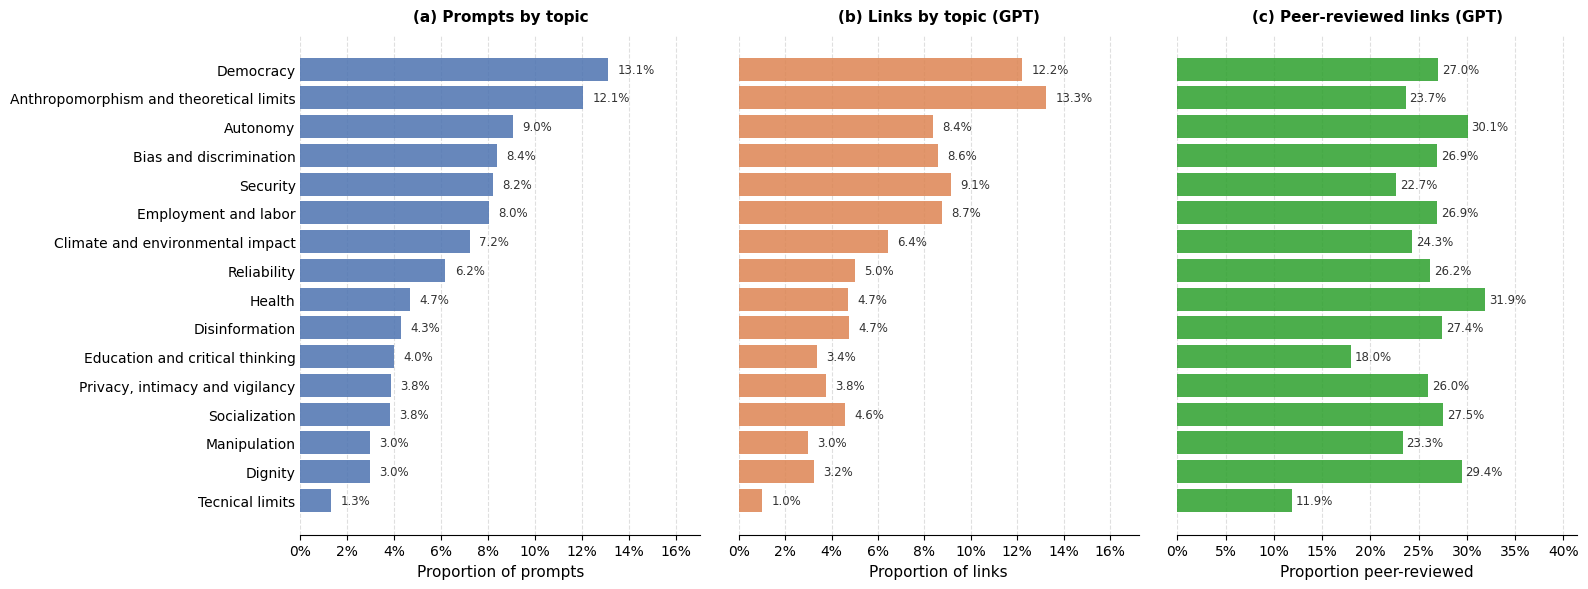

In [77]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick                                                 
                                                                                
# ── Datos ─────────────────────────────────────────────────────────────────      
prompts_per_topic = (                                                             
    prompts_topicos                                                               
    .drop_duplicates(subset=["prompt", "general topic"])                        
    .groupby("general topic")["prompt"]                                           
    .nunique()                                                                  
    .sort_values()                                                                
)                                                                               
prop_prompts = prompts_per_topic / prompts_per_topic.sum()                        
topic_order = prop_prompts.index                                                  
                                                                                
links_per_topic = df_gpt["general topic"].value_counts()                       
prop_links = (links_per_topic /                                                   
links_per_topic.sum()).reindex(topic_order).fillna(0)                             
                                                                                
#df_gpt["peer_reviewed"] = df_gpt["clasificacion"].apply(                    
   # lambda x: ast.literal_eval(x)["peer_reviewed"] if isinstance(x, str) else
#x["peer_reviewed"])                                                                               
pr_by_topic = (                                                                   
    df_gpt.groupby("general topic")["peer_reviewed"]                         
    .apply(lambda x: (x == "sí").sum() / len(x))                                  
    .reindex(topic_order)
)                                                                                 
                                                                                
# ── Figura con sharey ─────────────────────────────────────────────────────      
plt.rcParams.update({"font.family": "sans-serif", "font.size": 10})             
                                                                                
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 6), sharey=True)           
                                                                                
COLORS = ["#4C72B0", "#DD8452", "#2ca02c"]                                        
datasets = [                                                                      
      (ax1, prop_prompts.values, 'Proportion of prompts', '(a) Prompts by topic',   
  COLORS[0]),                                                                       
      (ax2, prop_links.values, 'Proportion of links', '(b) Links by topic (GPT)',       
  COLORS[1]),                                                                       
      (ax3, pr_by_topic.values, 'Proportion peer-reviewed', '(c) Peer-reviewed links (GPT)', COLORS[2]),                                                               
  ]                                                                                                
                                                                                
def style_ax(ax, first=False):                                                    
    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)                                       
    if not first:                                                               
        ax.spines["left"].set_visible(False)                                      
    ax.grid(axis="x", linestyle="--", alpha=0.4, zorder=0)                        
    ax.tick_params(axis="y", length=0)                                            
                                                                                
for i, (ax, values, xlabel, title, color) in enumerate(datasets):                 
    ax.barh(range(len(topic_order)), values, color=color, alpha=0.85, zorder=3) 
    ax.set_yticks(range(len(topic_order)))                                        
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))    
    ax.set_xlabel(xlabel, fontsize=11)                                            
    ax.set_title(title, fontsize=11, fontweight="bold", pad=10)                   
    ax.set_xlim(0, max(values) * 1.30)                                            
    style_ax(ax, first=(i == 0))                                                  
    for patch, val in zip(ax.patches, values):                                    
        ax.text(patch.get_width() + 0.004, patch.get_y() + patch.get_height() / 2,
                f"{val:.1%}", va="center", ha="left", fontsize=8.5,               
color="#333333")                                                                  
                                                                                
ax1.set_yticklabels(topic_order, fontsize=10)                                     
                                                                                
plt.tight_layout(w_pad=2)                                                         
#plt.savefig(PATH_OUT + "topic_distribution_gemini.pdf", bbox_inches="tight", dpi=300)                                                                          
plt.show()       